# Fase 4 — Eventos intensos e extremos

Objetivo: identificar quais condições dos preditores ERA5, incluindo diagnósticos derivados, diferenciam eventos de radar mais intensos. São usadas definições fixas e quantílicas. Os limiares fixos permanecem em **unidades numéricas da legenda do radar** até confirmação da unidade física.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

def resolve_output(rel):
    candidates = [Path(rel), Path("..") / rel, Path.cwd() / rel, Path.cwd().parent / rel]
    for p in candidates:
        if p.exists():
            return p.resolve()
    return Path(rel).resolve()

OUT = resolve_output("analysis_outputs/04_extremes")
print("Usando resultados em:", OUT)


Usando resultados em: /home/vsantos/repositories/rionowcastdf/analysis_outputs/04_extremes


In [2]:
def load_parquet(name):
    path = OUT / name
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()

def load_json(name):
    path = OUT / name
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}

summary=load_json("analysis_summary.json")
catalog=load_parquet("predictor_catalog.parquet")
thresholds=load_parquet("threshold_definitions.parquet")
prevalence=load_parquet("event_prevalence.parquet")
cond=load_parquet("conditional_predictor_stats.parquet")
effects=load_parquet("effect_sizes.parquet")
deciles=load_parquet("event_rate_by_predictor_decile.parquet")
npz=OUT/"extreme_samples.npz"
data=np.load(npz,allow_pickle=False) if npz.exists() else None


## 1. Definições de eventos

In [3]:
thresholds

,event_id,family,quantile,threshold,operator,label
0,fixed_ge_20,fixed,NaN,20.000000,>=,Radar >= 20
1,fixed_ge_25,fixed,NaN,25.000000,>=,Radar >= 25
2,fixed_ge_30,fixed,NaN,30.000000,>=,Radar >= 30
3,fixed_ge_35,fixed,NaN,35.000000,>=,Radar >= 35
4,fixed_ge_40,fixed,NaN,40.000000,>=,Radar >= 40
5,fixed_ge_45,fixed,NaN,45.000000,>=,Radar >= 45
6,fixed_ge_50,fixed,NaN,50.000000,>=,Radar >= 50
7,global_p90,global_quantile,0.90,0.000000,>,Radar > P90 global
8,global_p95,global_quantile,0.95,0.000000,>,Radar > P95 global
9,global_p99,global_quantile,0.99,20.000002,>,Radar > P99 global


Os quantis globais podem coincidir com zero por causa da grande massa de radar nulo. Por isso também são calculados quantis **somente entre valores positivos**, que descrevem melhor a intensidade condicional dos eventos.

## 2. Prevalência dos eventos

In [4]:
prevalence[["event_id","family","threshold","event_count","event_rate"]] if not prevalence.empty else prevalence

,event_id,family,threshold,event_count,event_rate
0,fixed_ge_20,fixed,20.000000,4542,0.015140
1,fixed_ge_25,fixed,25.000000,1450,0.004833
2,fixed_ge_30,fixed,30.000000,483,0.001610
3,fixed_ge_35,fixed,35.000000,473,0.001577
4,fixed_ge_40,fixed,40.000000,140,0.000467
5,fixed_ge_45,fixed,45.000000,25,0.000083
6,fixed_ge_50,fixed,50.000000,0,0.000000
7,global_p90,global_quantile,0.000000,4575,0.015250
8,global_p95,global_quantile,0.000000,4575,0.015250
9,global_p99,global_quantile,20.000002,2754,0.009180


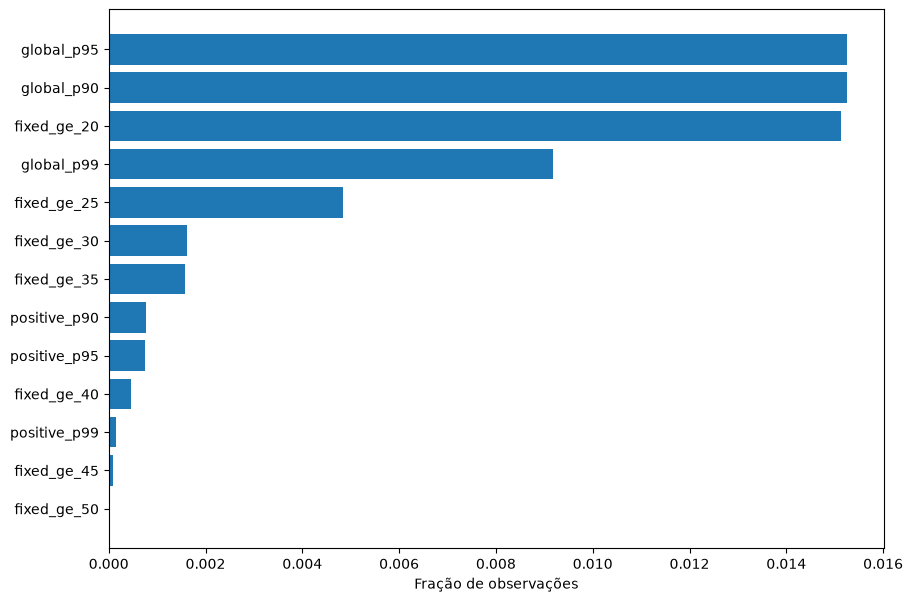

In [5]:
if not prevalence.empty:
    d=prevalence.sort_values("event_rate")
    fig,ax=plt.subplots(figsize=(10,7)); ax.barh(d["event_id"],d["event_rate"]); ax.set_xlabel("Fração de observações"); plt.show()

## 3. Diferença padronizada entre evento e não-evento

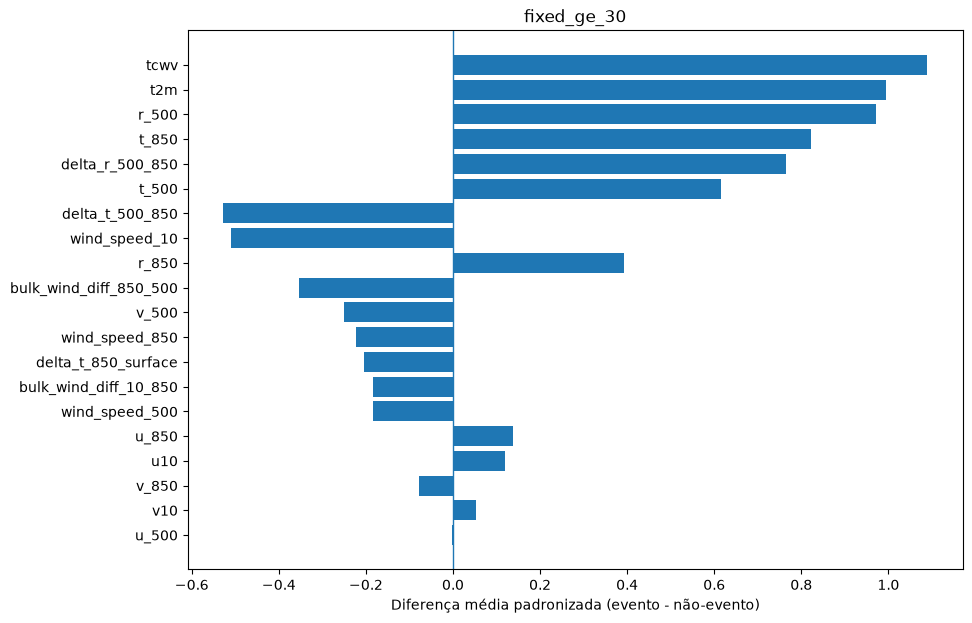

In [6]:
if not effects.empty:
    # Prioriza um limiar físico-numérico intermediário; cai para o primeiro disponível.
    event_id="fixed_ge_30" if "fixed_ge_30" in set(effects.event_id) else effects.event_id.iloc[0]
    d=effects[effects.event_id==event_id].copy(); d["abs_smd"]=d["standardized_mean_difference"].abs(); d=d.sort_values("abs_smd")
    fig,ax=plt.subplots(figsize=(10,7)); ax.barh(d["predictor"],d["standardized_mean_difference"]); ax.axvline(0,linewidth=1); ax.set_title(event_id); ax.set_xlabel("Diferença média padronizada (evento - não-evento)"); plt.show()

## 4. Matriz de efeito por limiar fixo

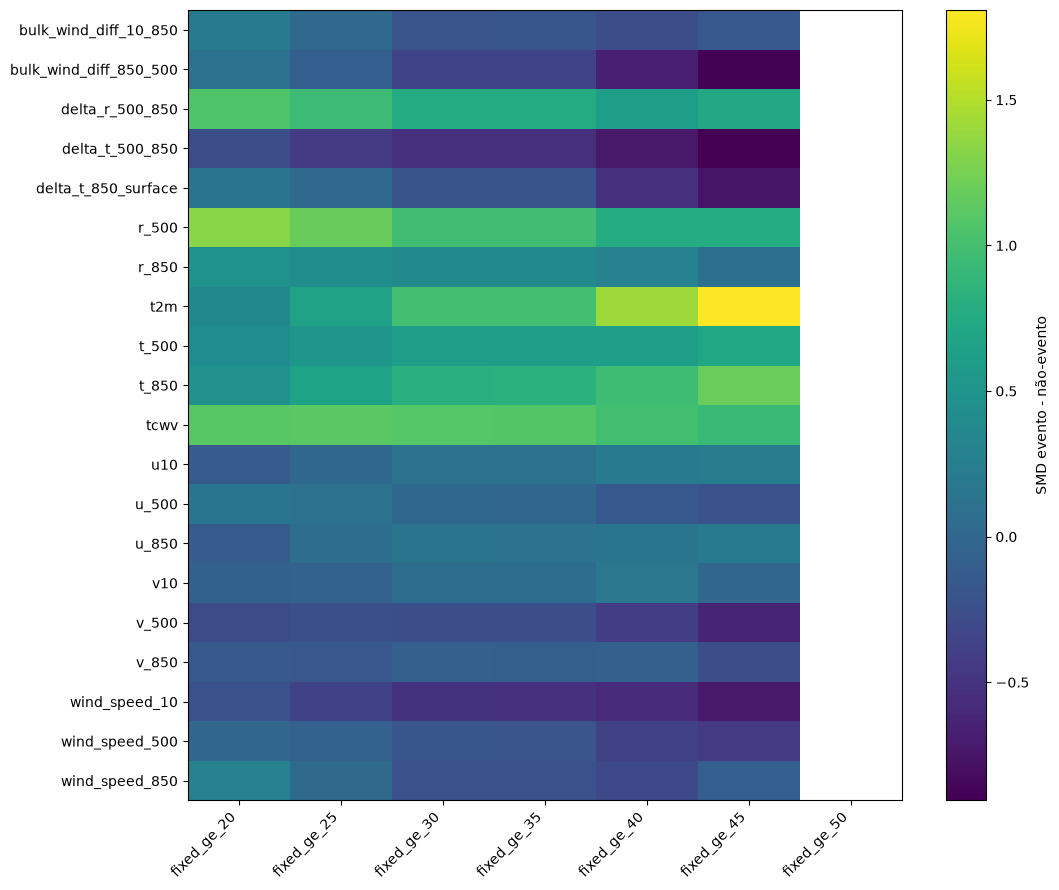

In [7]:
if not effects.empty:
    d=effects[effects.family=="fixed"]
    mat=d.pivot(index="predictor",columns="event_id",values="standardized_mean_difference")
    fig,ax=plt.subplots(figsize=(11,9)); im=ax.imshow(mat.values,aspect="auto")
    ax.set_xticks(range(len(mat.columns)),mat.columns,rotation=45,ha="right")
    ax.set_yticks(range(len(mat.index)),mat.index)
    fig.colorbar(im,ax=ax,label="SMD evento - não-evento"); fig.tight_layout(); plt.show()

## 5. Estatísticas condicionais de preditores selecionados

In [8]:
if not effects.empty and not cond.empty:
    event_id="fixed_ge_30" if "fixed_ge_30" in set(effects.event_id) else effects.event_id.iloc[0]
    top=effects[effects.event_id==event_id].assign(a=lambda d:d.standardized_mean_difference.abs()).sort_values("a",ascending=False).predictor.head(8)
    display(cond[(cond.event_id==event_id)&(cond.predictor.isin(top))][["predictor","group","n","mean","std","p25","median","p75","p95"]])

,predictor,group,n,mean,std,p25,median,p75,p95
80,tcwv,event,483,48.397214,5.233412,45.888788,48.958450,51.239038,56.470476
81,tcwv,non_event,299517,35.630830,11.722194,27.013250,35.158295,45.567848,53.943461
82,t2m,event,483,299.363276,3.911846,296.446136,299.238892,301.462219,307.059836
83,t2m,non_event,299517,296.054631,3.327011,294.060333,295.852661,298.131592,301.791504
88,t_850,event,483,291.200281,2.818327,289.560974,290.541473,292.525970,296.389767
89,t_850,non_event,299517,288.441609,3.356667,286.642365,288.866364,290.664246,293.020795
96,t_500,event,483,266.512110,1.429797,265.908112,266.530914,267.564667,268.443246
97,t_500,non_event,299517,265.193071,2.147333,263.650818,265.574188,266.794403,268.370215
98,r_500,event,483,66.663916,26.159921,44.372143,73.101570,87.110996,99.672431
99,r_500,non_event,299517,35.851860,31.692940,7.420298,24.760818,59.823189,95.857039


## 6. Probabilidade de extremo por decil do preditor

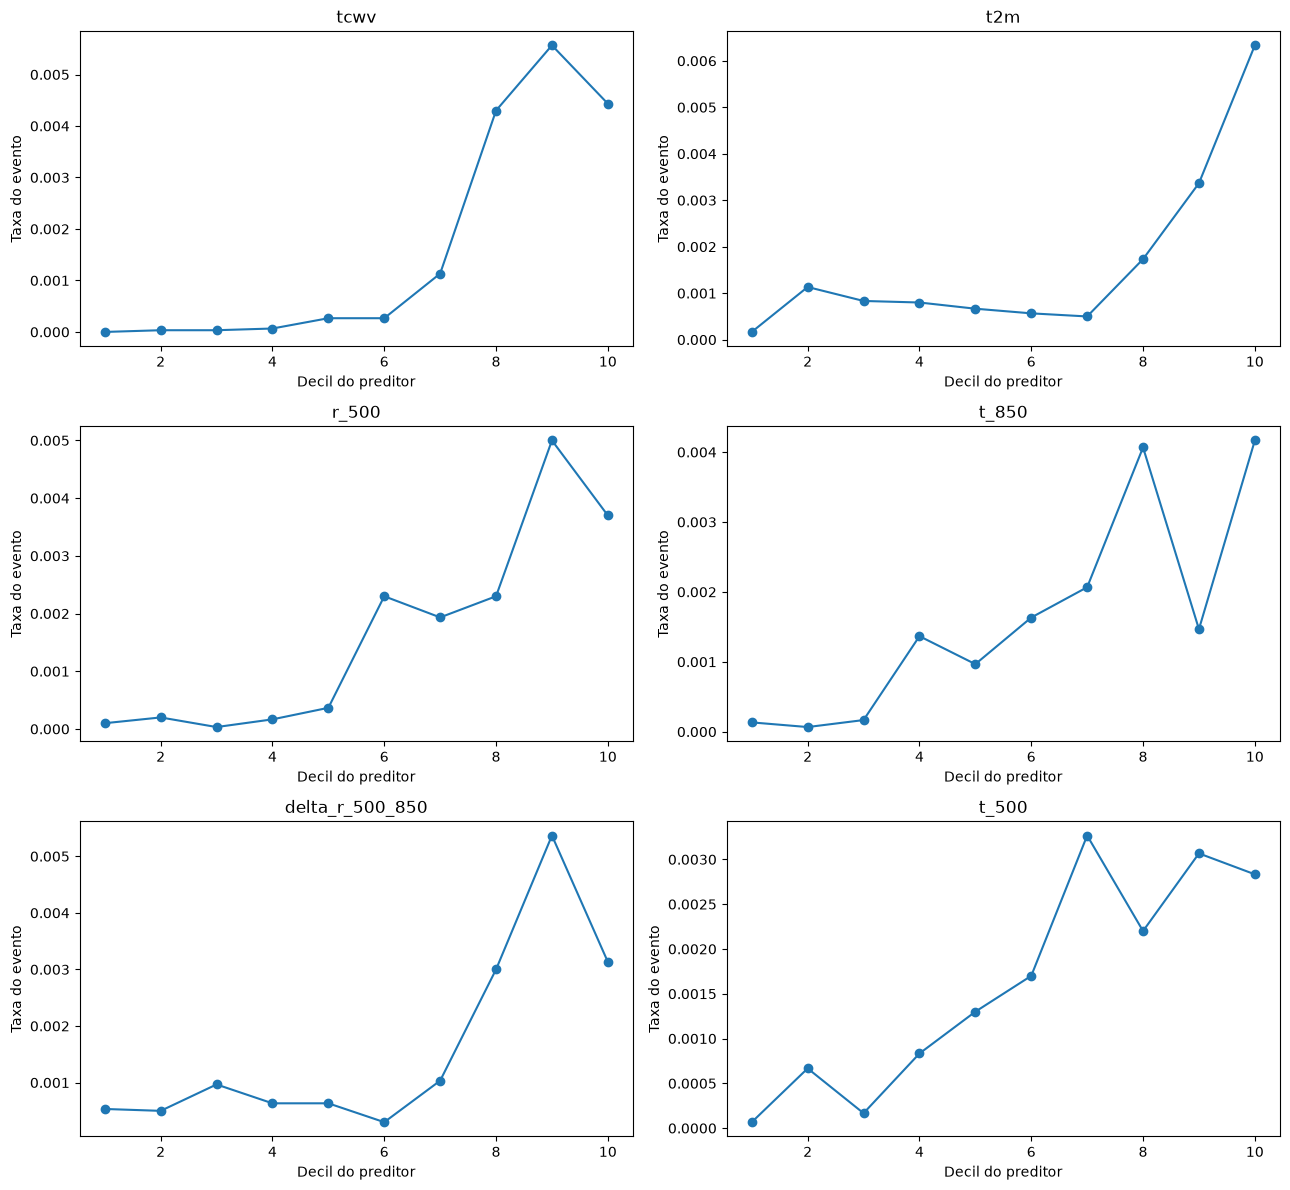

In [9]:
if not effects.empty and not deciles.empty:
    event_id="fixed_ge_30" if "fixed_ge_30" in set(deciles.event_id) else deciles.event_id.iloc[0]
    top=effects[effects.event_id==event_id].assign(a=lambda d:d.standardized_mean_difference.abs()).sort_values("a",ascending=False).predictor.head(6).tolist()
    fig,axes=plt.subplots(3,2,figsize=(13,12)); axes=axes.ravel()
    for ax,name in zip(axes,top):
        d=deciles[(deciles.event_id==event_id)&(deciles.predictor==name)].sort_values("decile")
        ax.plot(d["decile"],d["event_rate"],marker="o"); ax.set_title(name); ax.set_xlabel("Decil do preditor"); ax.set_ylabel("Taxa do evento")
    fig.tight_layout(); plt.show()

## 7. Comparação entre limiares quantílicos globais e positivos

In [10]:
if not prevalence.empty:
    q=prevalence[prevalence.family.isin(["global_quantile","positive_quantile"])][["event_id","family","threshold","event_rate"]]
    q

## 8. Síntese da Fase 4

A saída principal para orientar o CorrDiff é a combinação de: prevalência do evento, magnitude do efeito nos preditores e monotonicidade da taxa de evento por decil. Variáveis com associação global modesta podem apresentar forte separação nos eventos mais intensos.

In [11]:
pd.DataFrame([
    {"checagem":"Limiar fixo >=30 disponível","status":"OK" if "fixed_ge_30" in set(prevalence.event_id) else "REVISAR"},
    {"checagem":"Quantis positivos disponíveis","status":"OK" if (thresholds.family=="positive_quantile").any() else "REVISAR"},
    {"checagem":"Efeitos por preditor calculados","status":"OK" if len(effects)>0 else "REVISAR"},
    {"checagem":"Curvas por decil calculadas","status":"OK" if len(deciles)>0 else "REVISAR"},
])

,checagem,status
0,Limiar fixo >=30 disponível,OK
1,Quantis positivos disponíveis,OK
2,Efeitos por preditor calculados,OK
3,Curvas por decil calculadas,OK
